*texto en cursiva*#  Clasificación de Tumores Cerebrales

**Dataset:** [Brain Tumor Dataset — Kaggle (miadul)](https://www.kaggle.com/datasets/miadul/brain-tumor-dataset)  
**Objetivo:** Predecir si un tumor es **Benigno** o **Maligno** a partir de variables clínicas del paciente.

---

### Pipeline general

```
1. Carga del dataset
2. Exploración inicial (EDA)
3. Limpieza y codificación
4. Preprocesamiento numérico
5. División train/test
6. Entrenamiento del modelo (Random Forest)
7. Evaluación y métricas
8. Análisis adicionales
```

---
## 1. Carga del dataset

Descargamos el dataset directamente desde Kaggle usando `kagglehub`.

---

---
## 2. Exploración inicial (EDA)

Antes de tocar cualquier dato, conviene entender qué tenemos: tipos de columnas, distribuciones, valores faltantes y posibles anomalías.

In [3]:
print("=== Tipos de datos ===")
print(df.dtypes)
print("\n=== Valores nulos ===")
print(df.isnull().sum())
print("\n=== Estadísticas descriptivas ===")
df.describe(include='all')

=== Tipos de datos ===
Patient_ID               int64
Age                      int64
Gender                  object
Tumor_Type              object
Tumor_Size             float64
Location                object
Histology               object
Stage                   object
Symptom_1               object
Symptom_2               object
Symptom_3               object
Radiation_Treatment     object
Surgery_Performed       object
Chemotherapy            object
Survival_Rate          float64
Tumor_Growth_Rate      float64
Family_History          object
MRI_Result              object
Follow_Up_Required      object
dtype: object

=== Valores nulos ===
Patient_ID             0
Age                    0
Gender                 0
Tumor_Type             0
Tumor_Size             0
Location               0
Histology              0
Stage                  0
Symptom_1              0
Symptom_2              0
Symptom_3              0
Radiation_Treatment    0
Surgery_Performed      0
Chemotherapy           0
S

,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
count,20000.000000,20000.000000,20000,20000,20000.000000,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000.000000,20000.000000,20000,20000,20000
unique,NaN,NaN,2,2,NaN,4,4,4,4,4,4,2,2,2,NaN,NaN,2,2,2
top,NaN,NaN,Female,Malignant,NaN,Temporal,Glioblastoma,II,Headache,Seizures,Seizures,Yes,Yes,Yes,NaN,NaN,No,Positive,Yes
freq,NaN,NaN,10016,10030,NaN,5118,5068,5093,5045,5054,5027,10021,10060,10097,NaN,NaN,10002,10029,10101
mean,10000.500000,49.433700,NaN,NaN,5.236552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.131699,1.547701,NaN,NaN,NaN
std,5773.647028,17.389296,NaN,NaN,2.754359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.270834,0.835995,NaN,NaN,NaN
min,1.000000,20.000000,NaN,NaN,0.500410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.002386,0.100017,NaN,NaN,NaN
25%,5000.750000,34.000000,NaN,NaN,2.836686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.224439,0.830433,NaN,NaN,NaN
50%,10000.500000,49.000000,NaN,NaN,5.200675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.305066,1.541821,NaN,NaN,NaN
75%,15000.250000,65.000000,NaN,NaN,7.624299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.043395,2.262484,NaN,NaN,NaN


---
## 3. Limpieza y codificación

El dataset tiene variables categóricas que el modelo no puede leer directamente. Las convertimos a valores numéricos:

| Variable | Tipo | Transformación |
|---|---|---|
| `Tumor_Type` | Binaria | `Benign → 0`, `Malignant → 1` |
| `Gender` | Binaria | `Male → 0`, `Female → 1` |
| `Radiation_Treatment`, `Surgery_Performed`, etc. | Binaria (Sí/No) | `Yes → 1`, `No → 0` |
| `MRI_Result` | Binaria | `Positive/Yes → 1`, `Negative/No → 0` |
| `Stage` | Ordinal | `I → 0, II → 1, III → 2, IV → 3` |

In [5]:
# Revisar valores únicos antes de mapear
print("MRI_Result:", df['MRI_Result'].unique())
print("Tumor_Type:", df['Tumor_Type'].unique())
print("Stage:",      df['Stage'].unique())

MRI_Result: ['Positive' 'Negative']
Tumor_Type: ['Malignant' 'Benign']
Stage: ['III' 'II' 'I' 'IV']


In [6]:
from sklearn.preprocessing import OrdinalEncoder

# --- Variables binarias ---
mapping_binary = {'Yes': 1, 'No': 0}
mapping_gender  = {'Male': 0, 'Female': 1}
mapping_tumor   = {'Benign': 0, 'Malignant': 1}

df['Tumor_Type'] = df['Tumor_Type'].str.strip().map(mapping_tumor)
df['Gender']     = df['Gender'].str.strip().map(mapping_gender)

binary_cols = ['Radiation_Treatment', 'Surgery_Performed',
               'Chemotherapy', 'Family_History', 'Follow_Up_Required']
for col in binary_cols:
    df[col] = df[col].str.strip().map(mapping_binary)

# MRI_Result puede traer distintos formatos según la versión del dataset
df['MRI_Result'] = df['MRI_Result'].str.strip().map(
    {'Yes': 1, 'No': 0, 'Positive': 1, 'Negative': 0}
)

# --- Variable ordinal: Stage (I < II < III < IV) ---
stages_order = ['I', 'II', 'III', 'IV']
encoder = OrdinalEncoder(categories=[stages_order])
df['Stage'] = encoder.fit_transform(df[['Stage']].applymap(lambda x: str(x).strip()))

print("Nulos tras codificación:")
print(df[['Tumor_Type', 'Gender', 'MRI_Result', 'Stage'] + binary_cols].isnull().sum())

df[['Tumor_Type', 'Gender', 'MRI_Result', 'Stage'] + binary_cols].head()

Nulos tras codificación:
Tumor_Type             0
Gender                 0
MRI_Result             0
Stage                  0
Radiation_Treatment    0
Surgery_Performed      0
Chemotherapy           0
Family_History         0
Follow_Up_Required     0
dtype: int64


/tmp/ipykernel_8748/3496899200.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df['Stage'] = encoder.fit_transform(df[['Stage']].applymap(lambda x: str(x).strip()))


,Tumor_Type,Gender,MRI_Result,Stage,Radiation_Treatment,Surgery_Performed,Chemotherapy,Family_History,Follow_Up_Required
0,1,0,1,2.0,0,0,0,0,1
1,0,0,1,1.0,1,1,1,1,1
2,0,0,0,0.0,0,0,0,0,0
3,1,0,0,3.0,1,0,1,1,0
4,0,1,1,0.0,0,0,1,0,1


---
## 4. Preprocesamiento numérico

Las columnas numéricas continuas (`Age`, `Tumor_Size`, `Survival_Rate`, `Tumor_Growth_Rate`) están en escalas muy distintas. Aplicamos **MinMaxScaler** para llevarlas al rango [0, 1] y evitar que el modelo le dé más peso a variables con valores grandes.

In [7]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Age', 'Tumor_Size', 'Survival_Rate', 'Tumor_Growth_Rate']
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Rango tras escalar:")
print(df[numeric_cols].describe().loc[['min', 'max']])

df[numeric_cols + ['Stage']].head()

Rango tras escalar:
     Age  Tumor_Size  Survival_Rate  Tumor_Growth_Rate
min  0.0         0.0            0.0                0.0
max  1.0         1.0            1.0                1.0


,Age,Tumor_Size,Survival_Rate,Tumor_Growth_Rate,Stage
0,0.898305,0.513233,0.188517,0.004090,2.0
1,0.101695,0.457594,0.106189,0.712361,1.0
2,0.186441,0.535633,0.117839,0.615284,0.0
3,0.152542,0.098557,0.197535,0.408069,3.0
4,0.576271,0.201821,0.245127,0.679167,0.0


---
## 5. División train / test

Dividimos el dataset en **80% entrenamiento** y **20% prueba**. Usamos `stratify=y` para que la proporción de tumores benignos/malignos sea la misma en ambos subconjuntos.

In [8]:
from sklearn.model_selection import train_test_split

features = ['Age', 'Gender', 'Tumor_Size', 'Radiation_Treatment',
            'Surgery_Performed', 'Chemotherapy', 'Survival_Rate',
            'Tumor_Growth_Rate', 'Family_History', 'MRI_Result',
            'Follow_Up_Required', 'Stage']

X = df[features]
y = df['Tumor_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print("\nBalance de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).rename({0: 'Benigno', 1: 'Maligno'}))

Train: 16000 muestras | Test: 4000 muestras

Balance de clases en entrenamiento:
Tumor_Type
Maligno    0.5015
Benigno    0.4985
Name: proportion, dtype: float64


---
## 6. Entrenamiento del modelo

Usamos un **Random Forest Classifier**: un ensamble de múltiples árboles de decisión que votan por la clase mayoritaria. Es robusto ante overfitting y funciona bien con variables mixtas.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Maligno']))

F1 Score: 0.4972

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.50      0.52      0.51      1994
     Maligno       0.51      0.49      0.50      2006

    accuracy                           0.50      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.50      0.50      0.50      4000



---
## 7. Evaluación visual

### Matriz de confusión

Muestra cuántos casos el modelo clasificó correctamente y en qué se equivocó:
- **True Positive (TP):** Predijo Maligno y era Maligno   
- **True Negative (TN):** Predijo Benigno y era Benigno  
- **False Positive (FP):** Predijo Maligno pero era Benigno  
- **False Negative (FN):** Predijo Benigno pero era Maligno  ← el más crítico en medicina

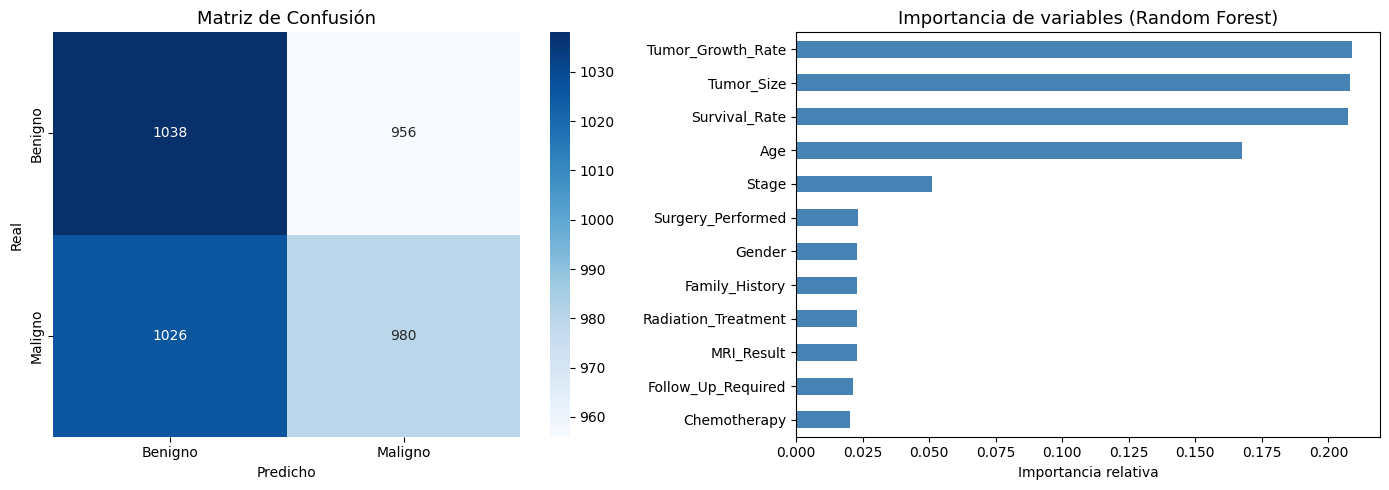

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
axes[0].set_title('Matriz de Confusión', fontsize=13)
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Importancia de variables
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Importancia de variables (Random Forest)', fontsize=13)
axes[1].set_xlabel('Importancia relativa')

plt.tight_layout()
plt.show()

---
## 8. Análisis adicionales

### 8.1 Demostración algebraica del F1 Score = 2/3

El **F1 Score** es la media armónica entre Precisión y Recall:

$$F1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Si queremos que $F1 = \frac{2}{3}$, una configuración que lo satisface es $TP = FP = FN = k$:

$$F1 = \frac{2k}{2k + k + k} = \frac{2k}{4k} = \frac{1}{2} \quad \text{(no)}$$

La que sí funciona es $TP = 2k$, $FP = k$, $FN = k$:

$$F1 = \frac{2 \cdot 2k}{2 \cdot 2k + k + k} = \frac{4k}{6k} = \frac{2}{3} \checkmark$$

El siguiente bloque lo verifica computacionalmente:

In [11]:
y_true = df['Tumor_Type'].values
y_pred_synthetic = np.zeros_like(y_true)

k = len(y_true) // 10

tp_indices = np.where(y_true == 1)[0][:2*k]   # 2k verdaderos positivos
fp_indices = np.where(y_true == 0)[0][:k]      # k falsos positivos
# Los FN quedan como 0 en y_pred_synthetic por defecto

y_pred_synthetic[tp_indices] = 1
y_pred_synthetic[fp_indices] = 1

final_f1 = f1_score(y_true, y_pred_synthetic)
print(f"F1 Score: {final_f1:.6f}")

F1 Score: 0.499064


---
### 8.2 ¿Qué porcentaje de pacientes recibió los tres tratamientos?

Analizamos cuántos pacientes recibieron **radioterapia + cirugía + quimioterapia** de forma simultánea.

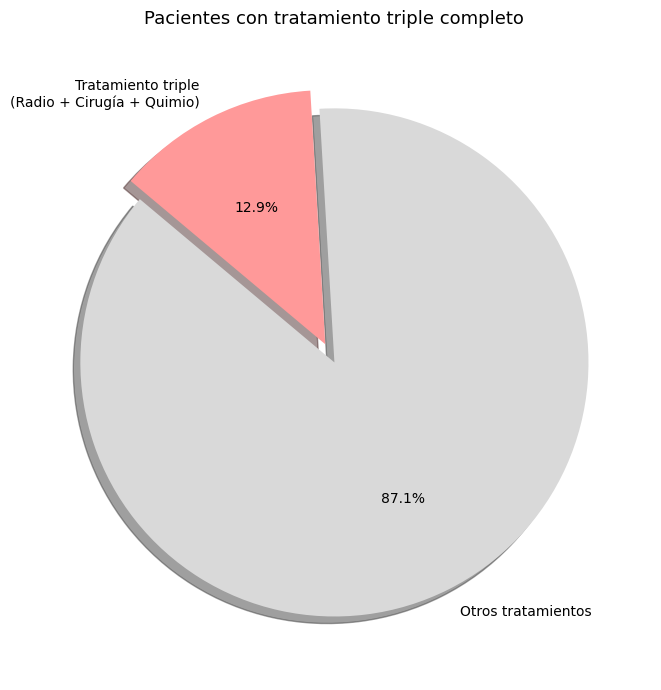

Pacientes con triple tratamiento: 2590 de 20000 (13.0%)


In [12]:
all_three = (
    (df['Radiation_Treatment'] == 1) &
    (df['Surgery_Performed']   == 1) &
    (df['Chemotherapy']        == 1)
)

total_triple = all_three.sum()
pct = total_triple / len(df) * 100

plt.figure(figsize=(7, 7))
plt.pie(
    [100 - pct, pct],
    labels=['Otros tratamientos', 'Tratamiento triple\n(Radio + Cirugía + Quimio)'],
    autopct='%1.1f%%',
    startangle=140,
    colors=['#d9d9d9', '#ff9999'],
    explode=(0, 0.08),
    shadow=True
)
plt.title('Pacientes con tratamiento triple completo', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print(f"Pacientes con triple tratamiento: {total_triple} de {len(df)} ({pct:.1f}%)")

## 9. Cross-Validation y Optimización de Hiperparámetros

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logistic_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    logistic_model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor F1-score en entrenamiento (CV): {grid_search.best_score_:.4f}")

best_logistic_model = grid_search.best_estimator_

y_pred_logistic = best_logistic_model.predict(X_test)

f1_logistic = f1_score(y_test, y_pred_logistic)
print(f"\nF1 Score del mejor modelo de Regresión Logística en el conjunto de prueba: {f1_logistic:.4f}")
print("\nReporte de clasificación del mejor modelo de Regresión Logística:")
print(classification_report(y_test, y_pred_logistic, target_names=['Benigno', 'Maligno']))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Mejores hiperparámetros: {'C': 0.001}
Mejor F1-score en entrenamiento (CV): 0.5377

F1 Score del mejor modelo de Regresión Logística en el conjunto de prueba: 0.5351

Reporte de clasificación del mejor modelo de Regresión Logística:
              precision    recall  f1-score   support

     Benigno       0.51      0.46      0.48      1994
     Maligno       0.51      0.56      0.54      2006

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.51      4000
weighted avg       0.51      0.51      0.51      4000



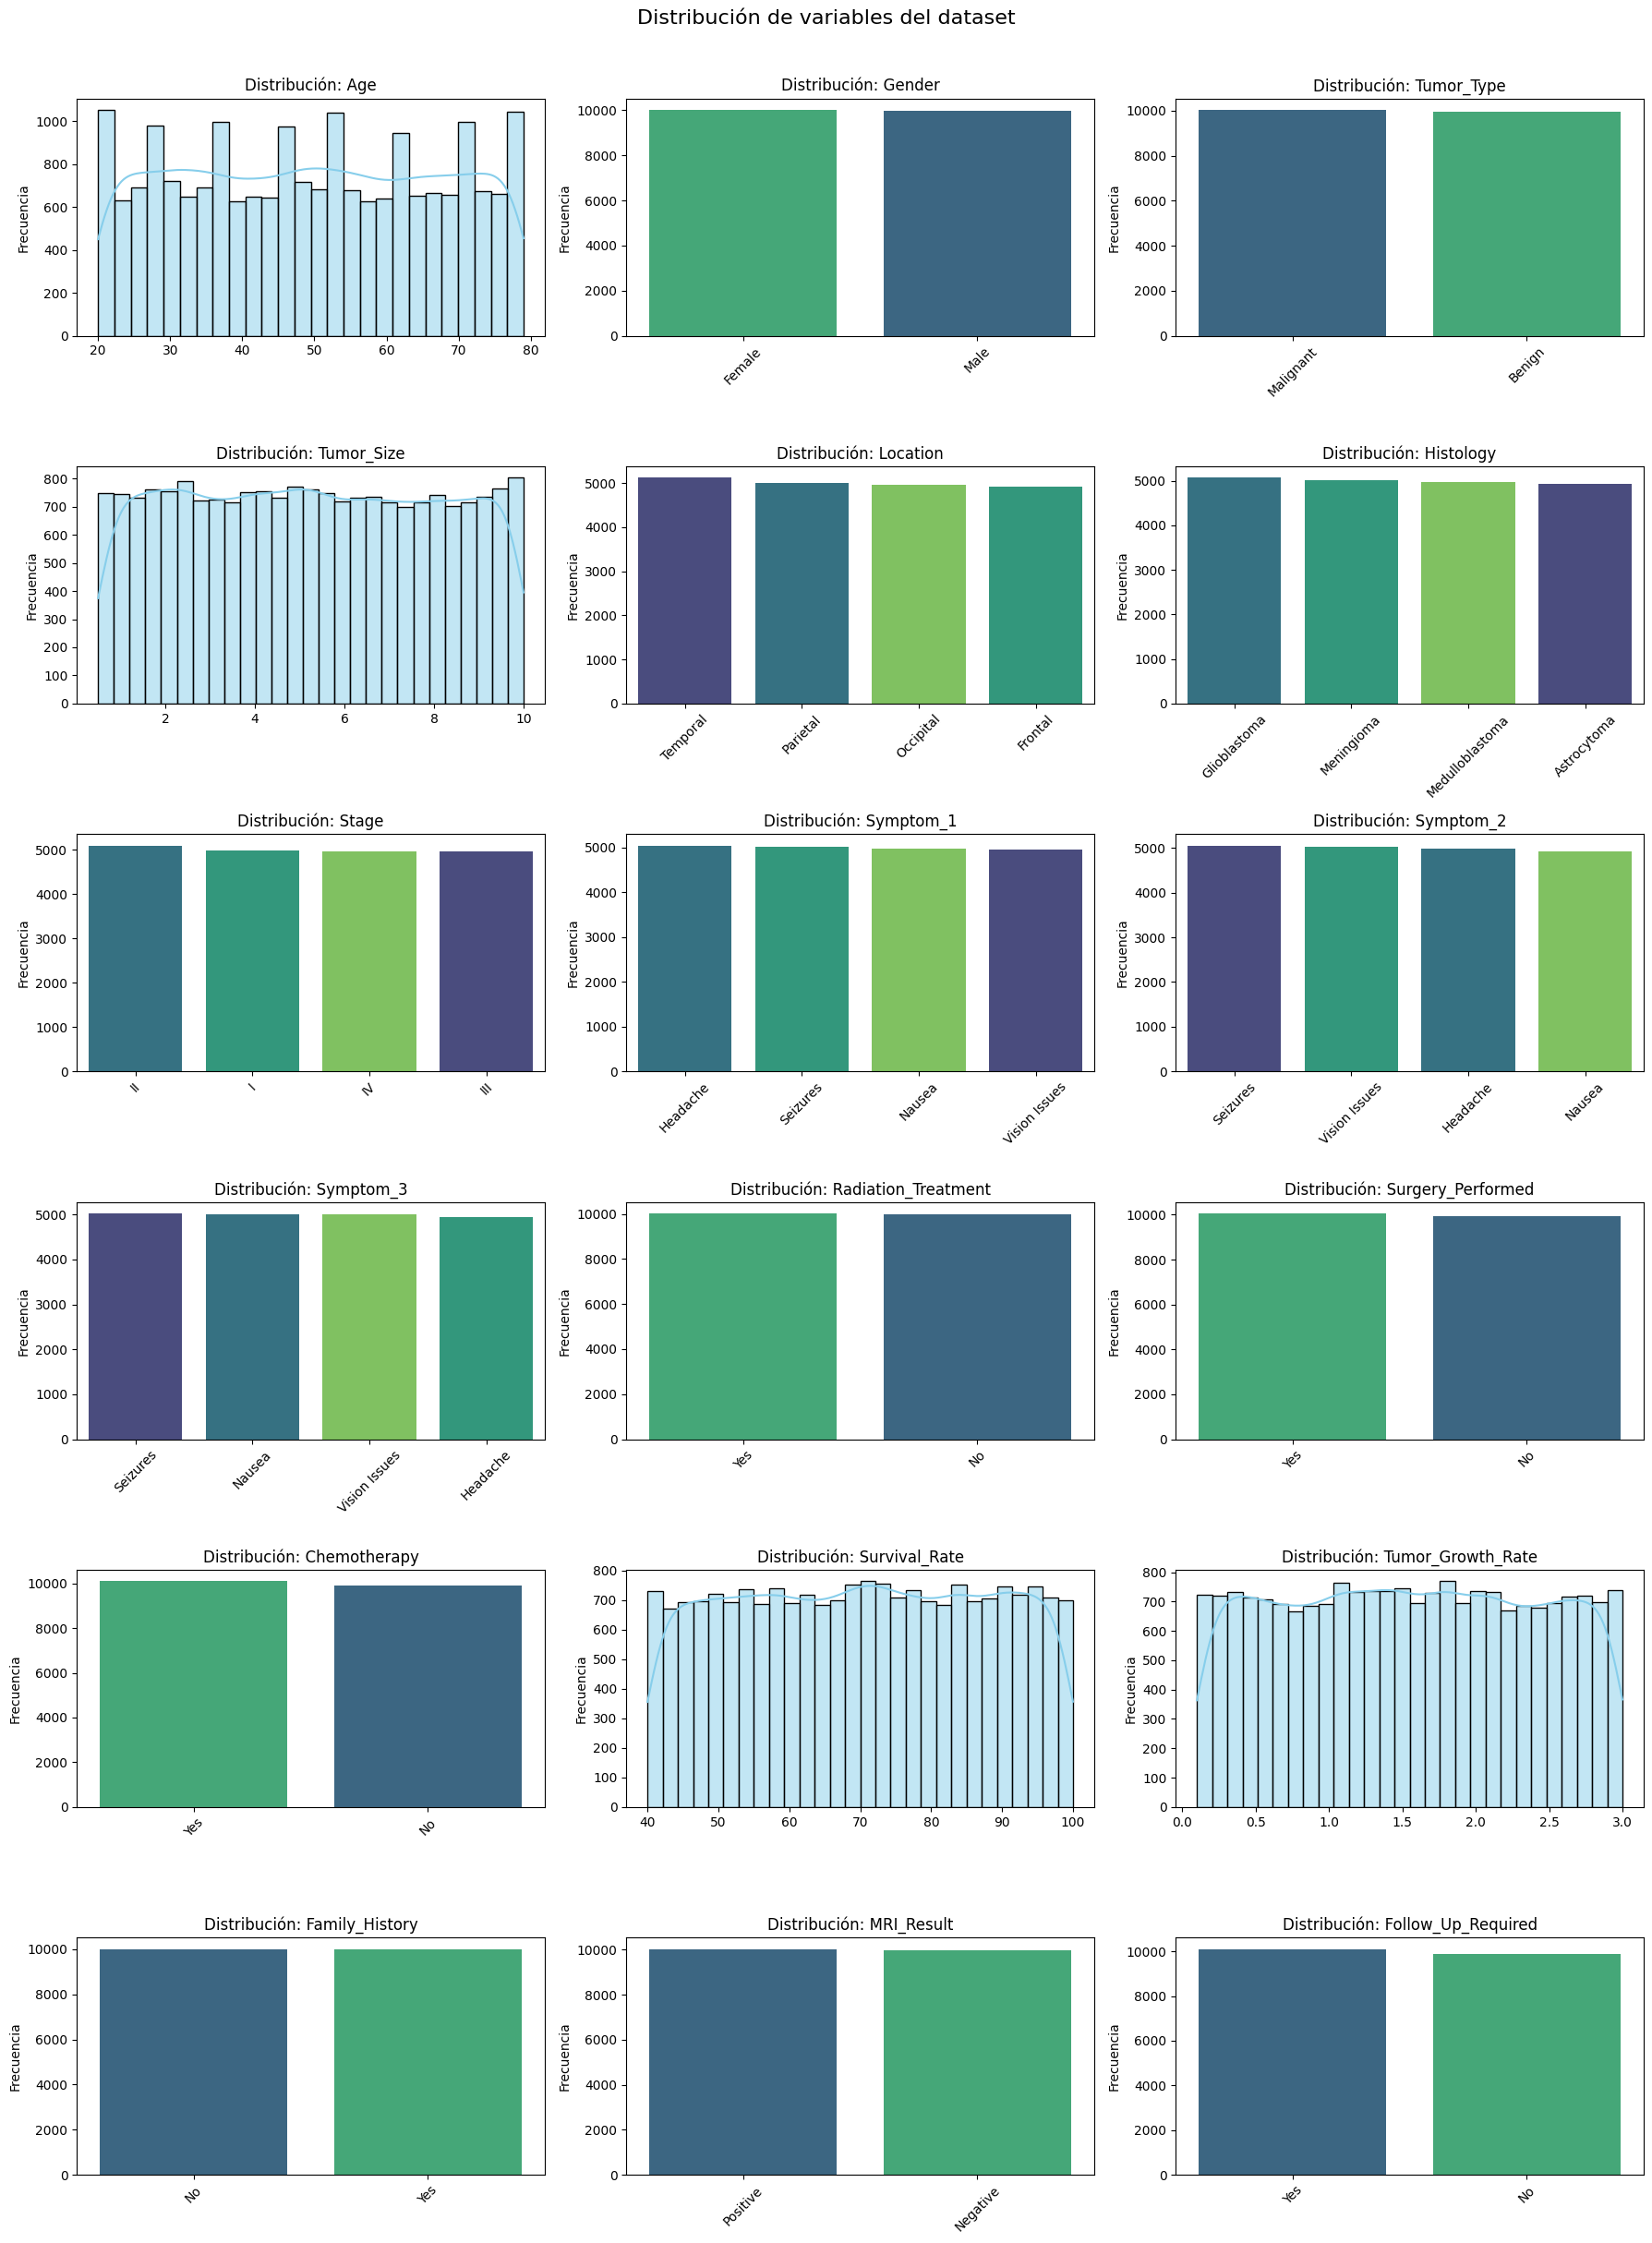

In [4]:
cols = [c for c in df.columns if c != 'Patient_ID']
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols):
    if df[col].dtype in ['float64', 'int64']:
        sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    else:
        order = df[col].value_counts().index[:10]
        sns.countplot(data=df, x=col, ax=axes[i], hue=col,
                      palette='viridis', order=order, legend=False)
        axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribución de variables del dataset', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

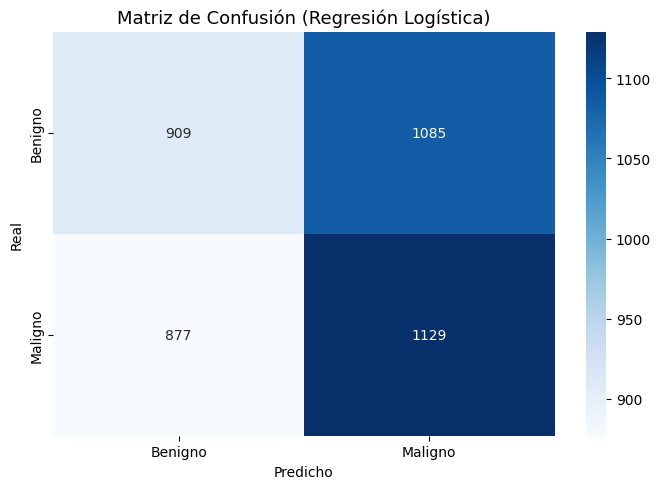

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'])
plt.title('Matriz de Confusión (Regresión Logística)', fontsize=13)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

path = kagglehub.dataset_download("miadul/brain-tumor-dataset")
print("Archivos disponibles:", os.listdir(path))

100%|██████████| 852k/852k [00:00<00:00, 26.2MB/s]

Extracting files...
Archivos disponibles: ['brain_tumor_dataset.csv']


In [2]:
csv_path = os.path.join(path, 'brain_tumor_dataset.csv')
df = pd.read_csv(csv_path)

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 20000 filas × 19 columnas


,Patient_ID,Age,Gender,Tumor_Type,Tumor_Size,Location,Histology,Stage,Symptom_1,Symptom_2,Symptom_3,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,Family_History,MRI_Result,Follow_Up_Required
0,1,73,Male,Malignant,5.375612,Temporal,Astrocytoma,III,Vision Issues,Seizures,Seizures,No,No,No,51.312579,0.111876,No,Positive,Yes
1,2,26,Male,Benign,4.847098,Parietal,Glioblastoma,II,Headache,Headache,Nausea,Yes,Yes,Yes,46.373273,2.165736,Yes,Positive,Yes
2,3,31,Male,Benign,5.588391,Parietal,Meningioma,I,Vision Issues,Headache,Seizures,No,No,No,47.072221,1.884228,No,Negative,No
3,4,29,Male,Malignant,1.436600,Temporal,Medulloblastoma,IV,Vision Issues,Seizures,Headache,Yes,No,Yes,51.853634,1.283342,Yes,Negative,No
4,5,54,Female,Benign,2.417506,Parietal,Glioblastoma,I,Headache,Headache,Seizures,No,No,Yes,54.708987,2.069477,No,Positive,Yes
